![Project Diagram](Violence_image.jpeg)

# Predicting the Severity of Political Violence in Kenya
*A Machine Learning Approach Using Historical Conflict Fatality Data*

---
**Team:** (Ctrl-Alt-Elite)  
**Contributors:** Kimutai Kevine, Mercy Wambui, Jackline Mwau, Richard Oketch, Winnie Nduva, Reeves Gonah  
**Date:** June - July 2026  
**Project:** Capstone Project  
**Data Sources:** [ACLED Africa Aggregated Conflict Dataset](https://acleddata.com/aggregated/aggregated-data-africa) | [WorldPop Population-Weighted Density Dataset](https://hub.worldpop.org/geodata/summary?id=50573)

---


## Abstract

This notebook documents the end-to-end pipeline for predicting the severity of political violence — measured as fatality counts — across Kenya's 47 counties at weekly resolution. The project combines nearly three decades of granular conflict event data from the Armed Conflict Location & Event Data (ACLED) project (1997–2026) with county-level demographic structure drawn from WorldPop population-weighted density estimates, interpolated across all years using inter-censal growth rates from the Kenya National Bureau of Statistics (KNBS).

The notebook is organised according to the CRISP-DM framework and covers: business understanding, dataset creation (including the population merge and interpolation pipeline), and data preparation (cleaning, missing value treatment, and initial feature engineering). Modelling, evaluation, and deployment follow in subsequent sections.

---


## 1. Business Understanding

---


### 1.1 Background

Kenya has experienced recurring episodes of political violence since the early 1990s, with the most severe flashpoints clustered around contested general elections — most notably the 2007/08 post-election crisis and the 2017 repeat presidential election. Political violence in Kenya is frequently linked to ethnic mobilisation, contested results, and localised historical grievances that resurface predictably around electoral cycles.

Despite this recurring pattern, conflict response in Kenya has historically been **reactive rather than predictive**. Security deployments, mediation efforts, and humanitarian pre-positioning tend to follow violence rather than anticipate it. This is not due to a lack of data — organisations like ACLED have systematically tracked conflict events, locations, actors, and fatalities across Kenya for nearly three decades. The gap is in **translating that raw event data into structured, actionable, forward-looking risk intelligence** at a level decision-makers can use: the county.


### 1.2 Business Problem

Political violence in Kenya is not random — it is patterned by geography, event type, population density, and temporal cycles aligned with elections and resource conflicts. Despite this predictability, early warning systems and humanitarian resource allocation in Kenya continue to rely primarily on expert judgement and lagged reporting, rather than systematic, data-driven forecasting.

**Formally, the business problem is:**

> Given historical patterns of conflict events, fatalities, and county-level demographic structure, can we predict the *severity* of political violence (fatalities) at the county-week level — well enough to flag high-risk counties before violence escalates, and to explain *why* those counties are at risk in terms decision-makers can act on?

**Why this is a hard problem:** the target variable, `FATALITIES` per county-week, is heavily right-skewed — 72.6% of observations are zero, while the maximum recorded value is 281 fatalities in a single county-week. Predicting rare, high-impact outcomes from a sparse and noisy signal is both analytically non-trivial and practically urgent.


### 1.3 Objectives

1. Identify statistically significant predictors of fatalities using feature importance scores and correlation analysis.
2. Quantify the marginal effect of population and density features on predicted fatality counts.
3. Build and evaluate four supervised regression models — Linear Regression, Random Forest, XGBoost, and Gradient Boosting — ranked by MAE, RMSE, and R² on a held-out test set.
4. Produce a county-level vulnerability index ranking all 47 counties by predicted high-fatality risk.
5. Deliver interpretable SHAP-based feature importance mapped to actionable policy recommendations.


### 1.4 Research Questions

1. Which features (event type, county, population density, temporal patterns) are the most statistically significant predictors of conflict fatalities?
2. What is the marginal effect of population and density on predicted fatality counts, independent of event-type effects?
3. Which of the four models best predicts fatality counts as measured by MAE, RMSE, and R² on the held-out test set?
4. Which of Kenya's 47 counties carry the highest predicted risk of severe political violence, and does this align with known historical hotspots?
5. According to SHAP value analysis, which features contribute most to predicted fatality severity, and what actionable policy recommendations can be derived from them?


### 1.5 Success Metrics

| Metric | Purpose |
|---|---|
| MAE | Average error in original fatality units; robust to outliers |
| RMSE | Penalises large misses heavily — important given the high-fatality tail |
| R² | Proportion of variance explained; target ≥ 0.60 on the held-out test set |

**Additional success criteria:**
- At least one model achieves R² ≥ 0.60 on the held-out (2022–2026) test set
- RMSE improves on the Linear Regression baseline by ≥ 20%
- Feature importance outputs align with domain knowledge
- County-level vulnerability rankings are validated against known real-world hotspots (Turkana, Nairobi, Mandera, Garissa)


---
## 2. Dataset Creation
---


### 2.0 Library Imports
Importing the necessary libraries.


In [1]:
!pip install missingno


  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.5 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.3 MB 1.2 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.3 MB 1.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.3 MB 1.0 MB/s eta 0:00:08
   ----- ------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

print('Libraries loaded.')


Libraries loaded.


c:\Users\Kim\Desktop\Predicting the Severity of Political Violence in Kenya\kenya-political-violence-risk-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.1 ACLED Kenya Conflict Data

The [Armed Conflict Location & Event Data (ACLED) dataset](https://acleddata.com/aggregated/aggregated-data-africa) was downloaded from the ACLED website, covering all of Africa from 1997 to June 2026.

**Pre-filtering note:** Prior to loading into this notebook, the full Africa file was filtered in Excel to retain only rows where `COUNTRY = 'Kenya'`, reducing the working file to 16,628 rows. This step was done purely for file size manageability and does not affect any analytical decisions — all subsequent transformations are performed here and are fully reproducible.


In [2]:
# Load pre-filtered ACLED Kenya file
acled = pd.read_csv('Africa_aggregated_data.csv')

print(f'ACLED Kenya rows: {len(acled):,}')
print(f'Columns: {acled.columns.tolist()}')
print(f'Counties: {acled["ADMIN1"].nunique()} unique counties')

ACLED Kenya rows: 16,627
Columns: ['WEEK', 'REGION', 'COUNTRY', 'ADMIN1', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'DISORDER_TYPE', 'ID', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE']
Counties: 47 unique counties


In [3]:
# Preview the first few rows
acled.head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
0,24-January-1998,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
1,16-January-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
2,25-September-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
3,07-August-2004,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185
4,02-April-2005,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185


### 2.2 Validate and Parse Dates

Verifying the `WEEK` column is correctly parsed as a datetime and extracting `YEAR` for use in the population merge.


In [4]:
# Ensure WEEK is in datetime format
acled['WEEK'] = pd.to_datetime(acled['WEEK'])

# Extract YEAR from WEEK (overwrite the existing YEAR column to ensure consistency)
acled['YEAR'] = acled['WEEK'].dt.year

print(f'Year range: {acled["YEAR"].min()} to {acled["YEAR"].max()}')

Year range: 1997 to 2026


### 2.3 WorldPop Population-Weighted Density (PWD) Data

The WorldPop PWD dataset provides county-level population and density estimates for Kenya at five census snapshots: 2000, 2005, 2010, 2015, and 2020. Each snapshot was originally a separate workbook, consolidated into one CSV and filtered for Kenya.

**Columns selected and why:**

| Column | What it represents |
|---|---|
| `Pop` | Total county population — used for normalisation and as a raw feature |
| `Density` | People per km² — raw density, interpretable and widely used |
| `Area` | County area in km² — large sparse counties behave differently from small dense ones |
| `PWD_G` | Population-weighted density (geometric mean) — reflects how densely people actually live, not just the county average over empty land |
| `PWD_D10` | Top density decile — captures whether a county has a concentrated urban core |


In [5]:
PWD_FILE = 'PWD_2020-2000_sub_national_100m.csv'

# The five columns we want — theoretically motivated and non-redundant
PWD_COLS = ['year', 'Adm_N', 'Pop', 'Density', 'Area', 'PWD_G', 'PWD_D10']
pwd_raw = pd.read_csv(PWD_FILE, usecols=PWD_COLS)

print(f'Stacked PWD table: {pwd_raw.shape[0]} rows ({pwd_raw["year"].nunique()} years x {pwd_raw["Adm_N"].nunique()} counties)')
pwd_raw.head(10)

Stacked PWD table: 235 rows (5 years x 47 counties)


,year,Adm_N,Pop,Density,Area,PWD_G,PWD_D10
0,2020,Baringo,772211,72.0,10718.1,135.5,13704.2
1,2020,Bomet,1066552,446.5,2388.7,594.7,9975.2
2,2020,Bungoma,2050866,571.4,3589.1,796.2,12482.1
3,2020,Busia,936016,562.1,1665.2,676.7,11317.2
4,2020,Elgeyo-Marakwet,496199,176.2,2815.6,252.2,3153.8
5,2020,Embu,635018,225.7,2814.2,443.6,20263.5
6,2020,Garissa,1522617,34.6,44043.9,367.0,36448.2
7,2020,Homa Bay,1163389,377.3,3083.4,511.3,13802.0
8,2020,Isiolo,184769,7.2,25551.4,82.9,11453.6
9,2020,Kajiado,984921,45.0,21909.9,340.4,37552.6


**Note:**  

The PWD data only has values at 5 census snapshots (2000, 2005, 2010, 2015, 2020). We need a population value for every county in every year covered by ACLED (1997–2026). The approach is:

1. Standardise county names to match ACLED exactly
2. Build a full county × year grid (47 counties × 30 years = 1,410 rows)
3. Place known census values at the snapshot years
4. **Interpolate linearly** between known years — population grows continuously, not in 5-year steps
5. **Backfill** years before 2000 using the 2000 value (earliest available data)
6. **Extrapolate** years after 2020 using Kenya's 2009–2019 inter-censal growth rate of **2.2%** per year, as published in the 2019 Kenya Population and Housing Census (KNBS Volume I, Figure 2.2)


### 2.4 Standardise County Names

Two counties have different naming conventions between ACLED and WorldPop:

| WorldPop name | ACLED name |
|---|---|
| Elgeyo-Marakwet | Elgeyo Marakwet |
| Murang'a | Muranga |

Standardising PWD names to match ACLED so the merge works cleanly.


In [6]:
# Rename PWD county names to match ACLED
county_name_map = {
    'Elgeyo-Marakwet': 'Elgeyo Marakwet',
    "Murang'a":         'Muranga'
}
pwd_raw['Adm_N'] = pwd_raw['Adm_N'].replace(county_name_map)

# Confirm all PWD counties now match ACLED
acled_counties = set(acled['ADMIN1'].unique())
pwd_counties   = set(pwd_raw['Adm_N'].unique())

unmatched = acled_counties.symmetric_difference(pwd_counties)
if unmatched:
    print(f'WARNING — unmatched counties: {unmatched}')
else:
    print(f'All {len(acled_counties)} county names match between ACLED and PWD.')


All 47 county names match between ACLED and PWD.


### 2.5 Build the Full County × Year Grid


In [7]:
# All 47 counties and every year from 1997 to 2026
all_counties = sorted(pwd_raw['Adm_N'].unique())
all_years    = list(range(1997, 2027))

# Create a grid of every county-year combination
grid = pd.MultiIndex.from_product(
    [all_counties, all_years],
    names=['Adm_N', 'year']
).to_frame(index=False)

print(f'Full county-year grid: {len(grid):,} rows ({len(all_counties)} counties x {len(all_years)} years)')


Full county-year grid: 1,410 rows (47 counties x 30 years)


In [8]:
# Merge the known census values onto the grid
# Rows without a census snapshot will have NaN for population columns
pwd_grid = grid.merge(pwd_raw, on=['Adm_N', 'year'], how='left')

print(f'Grid after merging census values: {pwd_grid.shape}')
print(f'Rows with known population: {pwd_grid["Pop"].notna().sum()} (should be 47 x 5 = 235)')
print(f'Rows needing interpolation: {pwd_grid["Pop"].isna().sum()}')


Grid after merging census values: (1410, 7)
Rows with known population: 235 (should be 47 x 5 = 235)
Rows needing interpolation: 1175


### 2.6 Interpolate, Backfill, and Extrapolate

For each county separately:
- **Between 2000 and 2020**: linear interpolation between the 5 known census values
- **Before 2000**: backfill with the 2000 value (earliest available data)
- **After 2020**: apply 2.2% compound annual growth rate from the KNBS 2019 Census

This applies to all 5 PWD columns consistently.


In [9]:
PWD_VALUE_COLS = ['Pop', 'Density', 'Area', 'PWD_G', 'PWD_D10']
GROWTH_RATE = 0.022  # 2.2% per year — KNBS 2019 Census inter-censal rate 2009-2019

def fill_county_population(group):
    """
    For a single county's year series:
    1. Interpolate linearly between known census years
    2. Backfill years before 2000 with the 2000 value
    3. Extrapolate years after 2020 using 2.2% compound annual growth
    """
    group = group.sort_values('year').copy()
    for col in PWD_VALUE_COLS:
        # Step 1: linear interpolation between known census snapshots
        group[col] = group[col].interpolate(method='linear', limit_area='inside')
        # Step 2: backfill years before 2000 using the earliest known value
        group[col] = group[col].bfill()
        # Step 3: extrapolate years after 2020 using compound growth
        base_mask = group['year'] == 2020
        if base_mask.any():
            base_value = group.loc[base_mask, col].values[0]
            post_mask  = group['year'] > 2020
            years_after = group.loc[post_mask, 'year'] - 2020
            group.loc[post_mask, col] = base_value * ((1 + GROWTH_RATE) ** years_after.values)
    return group


In [10]:
# Apply county by county
pwd_filled = (
    pwd_grid
    .groupby('Adm_N', group_keys=False)
    .apply(fill_county_population)
    .reset_index(drop=True)
)

# Verify no NaN values remain
remaining_nulls = pwd_filled[PWD_VALUE_COLS].isna().sum()
print('Remaining NaN values per column after interpolation:')
print(remaining_nulls)
print(f'\nTotal rows in reference table: {len(pwd_filled):,}')


Remaining NaN values per column after interpolation:
Pop        0
Density    0
Area       0
PWD_G      0
PWD_D10    0
dtype: int64

Total rows in reference table: 1,410


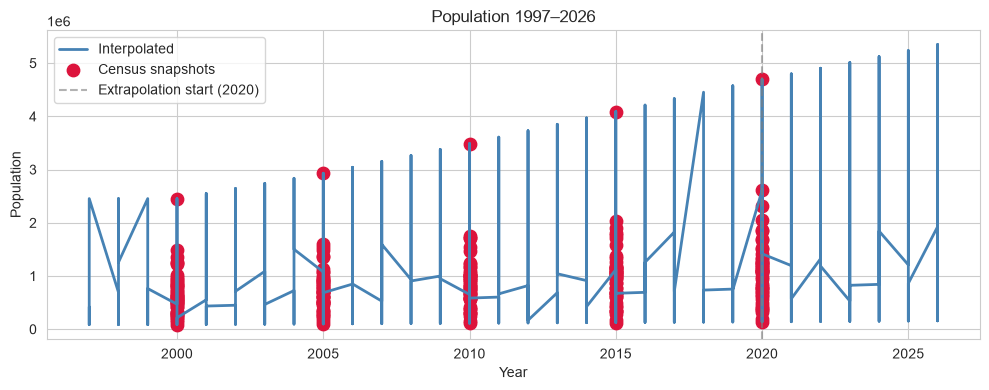

In [21]:
# Sanity check — plot Baringo population to confirm smooth interpolation
# Sanity check — plot population to confirm smooth interpolation

baringo = pwd_filled.sort_values('year')

census_years = [2000, 2005, 2010, 2015, 2020]
baringo_census = baringo[baringo['year'].isin(census_years)]

plt.figure(figsize=(10, 4))
plt.plot(baringo['year'], baringo['Pop'],
         color='steelblue', linewidth=2,
         label='Interpolated')

plt.scatter(baringo_census['year'], baringo_census['Pop'],
            color='crimson', s=80,
            label='Census snapshots')

plt.axvline(2020,
            color='gray',
            linestyle='--',
            alpha=0.6,
            label='Extrapolation start (2020)')

plt.title('Population 1997–2026')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.tight_layout()
plt.show()


**Note:**  
Red dots = known census values. Blue line = interpolated/extrapolated smoothly between them. The dashed line marks where 2.2% annual extrapolation begins.


### 2.7 Merge Population Features onto ACLED

Attaching the 5 population features to each ACLED row using a **left merge** on county name and year.

A left merge because:
- Every ACLED row is kept, regardless of whether a matching population row exists
- Population values are attached where county + year matches
- Counties that had no conflict events in a given year simply do not appear in ACLED and do not need a row in the merged dataset


In [17]:
# Prepare the reference table for merging
pwd_merge = pwd_filled[['Adm_N', 'year'] + PWD_VALUE_COLS].copy()
pwd_merge = pwd_merge.rename(columns={'Adm_N': 'ADMIN1', 'year': 'YEAR'})

# Rename columns to make them clearly identifiable in the merged dataset
pwd_merge = pwd_merge.rename(columns={
    'Pop':     'PWD_POPULATION',
    'Density': 'PWD_DENSITY',
    'Area':    'PWD_AREA_KM2',
    'PWD_G':   'PWD_G',
    'PWD_D10': 'PWD_D10'
})

print('Population reference table ready for merge:')
print(f'  Shape: {pwd_merge.shape}')
print(f'  Columns: {pwd_merge.columns.tolist()}')


KeyError: "['Adm_N'] not in index"

In [18]:
pwd_filled.columns.tolist()

['year', 'Pop', 'Density', 'Area', 'PWD_G', 'PWD_D10']

In [15]:
# Perform the merge
rows_before = len(acled)
df = acled.merge(pwd_merge, on=['ADMIN1', 'YEAR'], how='left')
rows_after  = len(df)

print(f'Rows before merge: {rows_before:,}')
print(f'Rows after merge:  {rows_after:,}')
print(f'Row count preserved: {rows_before == rows_after}')
print()

# Check for any rows that did not get a population value
unmatched = df['PWD_POPULATION'].isna().sum()
print(f'Rows without population after merge: {unmatched}')


Rows before merge: 16,627
Rows after merge:  16,627
Row count preserved: True

Rows without population after merge: 0


### 2.8 Final Working Dataset Overview


In [16]:
# Final shape and column audit
print('=== FINAL MERGED DATASET ===')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns:')
for col in df.columns:
    null_count = df[col].isna().sum()
    null_pct   = null_count / len(df) * 100
    print(f'  {col:<30} dtype={str(df[col].dtype):<12} nulls={null_count} ({null_pct:.1f}%)')


=== FINAL MERGED DATASET ===
Shape: 16,627 rows x 19 columns

Columns:
  WEEK                           dtype=datetime64[ns] nulls=0 (0.0%)
  REGION                         dtype=object       nulls=0 (0.0%)
  COUNTRY                        dtype=object       nulls=0 (0.0%)
  ADMIN1                         dtype=object       nulls=0 (0.0%)
  EVENT_TYPE                     dtype=object       nulls=0 (0.0%)
  SUB_EVENT_TYPE                 dtype=object       nulls=0 (0.0%)
  EVENTS                         dtype=int64        nulls=0 (0.0%)
  FATALITIES                     dtype=int64        nulls=0 (0.0%)
  POPULATION_EXPOSURE            dtype=float64      nulls=4897 (29.5%)
  DISORDER_TYPE                  dtype=object       nulls=0 (0.0%)
  ID                             dtype=int64        nulls=0 (0.0%)
  CENTROID_LATITUDE              dtype=float64      nulls=0 (0.0%)
  CENTROID_LONGITUDE             dtype=float64      nulls=0 (0.0%)
  YEAR                           dtype=int32        

In [17]:
# Preview
df.head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
0,1998-01-24,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.40,4938.30
1,1999-01-16,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
2,1999-09-25,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
3,2004-08-07,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185,2004,479975.8,44.8,10718.1,90.52,8113.42
4,2005-04-02,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,2005,495049.0,46.2,10718.1,95.30,8907.20


In [18]:
# Save the merged dataset
OUTPUT_FILE = 'kenya_conflict_merged.csv'
df.to_csv(OUTPUT_FILE, index=False)
print(f'Dataset saved to {OUTPUT_FILE}')
print(f'Shape: {df.shape}')


Dataset saved to kenya_conflict_merged.csv
Shape: (16627, 19)


### Summary of Dataset Creation Decisions

Primarily, the WorldPop population dataset was loaded, selecting only necessary columns so as to prevent unnecessary cleaning, interpolated for intermediary values absent betwee the five year periods in which the data was provided, and the county names cleaned for similarity across both datasets. The datsets were then merged using a left join on the basis of year and county, such that only the acled rows with weekly information were kept. The decisions made along the way are tabulated below, as well as their rationale.

| Decision | Rationale |
|---|---|
| Pre-filtered ACLED to Kenya in Excel | File size only — no analytical impact |
| Selected 5 PWD columns from 25 available | Pop, Density, Area, PWD_G, PWD_D10 — theoretically motivated, non-redundant |
| Standardised 2 county names | Elgeyo-Marakwet and Murang'a spelling differences between sources |
| Linear interpolation between census years | Population grows continuously, not in 5-year steps |
| Backfill pre-2000 with 2000 value | No earlier data available; earliest known value is best available prior |
| 2.2% growth rate for post-2020 | KNBS 2019 Census inter-censal rate 2009–2019 (Figure 2.2) |
| Left merge on county + year | Preserves all ACLED rows; attaches population only where events exist |


---
## 3. Data Understanding
---


### 3.1 Dataset Preview
Taking a look at the now identified working dataset;

In [19]:
df.head()


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
0,1998-01-24,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.40,4938.30
1,1999-01-16,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
2,1999-09-25,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
3,2004-08-07,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185,2004,479975.8,44.8,10718.1,90.52,8113.42
4,2005-04-02,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,2005,495049.0,46.2,10718.1,95.30,8907.20


In [20]:
# Shape
print(f'Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.')


Dataset contains 16,627 rows and 19 columns.


**Note:**  
The dataset contains 16,627 rows and columns spanning conflict event details, temporal markers, and population features derived from the WorldPop PWD merge above.


In [21]:
# Data types and null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16627 entries, 0 to 16626
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   WEEK                 16627 non-null  datetime64[ns]
 1   REGION               16627 non-null  object        
 2   COUNTRY              16627 non-null  object        
 3   ADMIN1               16627 non-null  object        
 4   EVENT_TYPE           16627 non-null  object        
 5   SUB_EVENT_TYPE       16627 non-null  object        
 6   EVENTS               16627 non-null  int64         
 7   FATALITIES           16627 non-null  int64         
 8   POPULATION_EXPOSURE  11730 non-null  float64       
 9   DISORDER_TYPE        16627 non-null  object        
 10  ID                   16627 non-null  int64         
 11  CENTROID_LATITUDE    16627 non-null  float64       
 12  CENTROID_LONGITUDE   16627 non-null  float64       
 13  YEAR                 16627 non-

**Note:**  
`POPULATION_EXPOSURE` is the only column with missing values (~29.4%). All other columns are fully populated.
This confirms the dataset is structurally clean and ready for data preparation.


In [22]:
# Statistical summary
df.describe(include='all')


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
count,16627,16627,16627,16627,16627,16627,16627.000000,16627.000000,1.173000e+04,16627,16627.000000,16627.000000,16627.000000,16627.000000,1.662700e+04,16627.000000,16627.000000,16627.000000,1.662700e+04
unique,NaN,1,1,47,6,24,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Eastern Africa,Kenya,Nairobi,Protests,Peaceful protest,NaN,NaN,NaN,Political violence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,16627,16627,1932,5474,4734,NaN,NaN,NaN,8000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2019-10-10 23:34:06.286161152,NaN,NaN,NaN,NaN,NaN,1.294882,0.949600,3.774653e+04,NaN,1557.682444,-0.360952,36.905008,2019.288567,1.551337e+06,1130.021052,12907.134916,3512.448162,8.692382e+04
min,1997-01-11 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.000000e+00,NaN,1535.000000,-4.119800,34.205100,1997.000000,8.530900e+04,3.700000,260.900000,17.300000,1.665200e+03
25%,2017-01-14 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,5.358750e+03,NaN,1547.000000,-1.301900,35.306000,2017.000000,8.065620e+05,65.224438,2349.863681,244.480000,1.332418e+04
50%,2022-10-22 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.582100e+04,NaN,1559.000000,-0.467500,36.827000,2022.000000,1.241895e+06,274.260000,3589.100000,615.880000,2.252690e+04
75%,2024-10-12 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,3.932300e+04,NaN,1565.000000,0.497900,37.777500,2024.000000,1.820566e+06,653.831618,14110.443056,1058.977284,4.199972e+04
max,2026-06-20 00:00:00,NaN,NaN,NaN,NaN,NaN,21.000000,281.000000,1.475399e+06,NaN,1581.000000,3.220100,40.711200,2026.000000,5.349955e+06,7518.607822,81254.702191,28521.210865,1.743386e+06


**Note:**  
`FATALITIES` is dominated by zeros (median = 0, mean < 1) with a small number of extreme events pulling the max to 281 — a classic rare-event, long-tail problem.
Most modelling difficulty in this project will come from this distribution, not from messy data.
Categorically, the data skews toward non-lethal unrest: 'Protests' and 'Peaceful protest' are the most common event types.


### 3.2 Duplicate Check


In [23]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')


Number of duplicate rows: 0


**Note:**  
0 duplicate rows found. No action required.


### 3.3 Skewness of Key Numeric Columns


In [24]:
numeric_skew_cols = ['EVENTS', 'FATALITIES', 'PWD_POPULATION', 'PWD_DENSITY']
df[numeric_skew_cols].skew()


EVENTS             6.114555
FATALITIES        26.131026
PWD_POPULATION     1.699592
PWD_DENSITY        2.097458
dtype: float64

**Note:**
- `FATALITIES` (skew ~26) → extremely skewed. Almost all values are 0, with a few extreme outliers up to 281. Confirms the zero-inflation problem.
- `EVENTS` (skew ~6) → also right-skewed but less extreme. Most county-weeks have just 1 event.
- `PWD_POPULATION` and `PWD_DENSITY` → moderately skewed, driven by outlier counties like Nairobi. These will be log-transformed in data preparation.


### 3.4 Correlation Between Numeric Features


In [25]:
df.corr(numeric_only=True)


,EVENTS,FATALITIES,POPULATION_EXPOSURE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
EVENTS,1.000000,0.200076,0.422786,0.032327,-0.036531,-0.043209,0.027041,0.206028,0.195513,-0.063745,0.205163,0.046013
FATALITIES,0.200076,1.000000,0.123113,0.043812,0.098998,0.060109,-0.182143,-0.058070,-0.040378,0.127712,-0.030950,0.016928
POPULATION_EXPOSURE,0.422786,0.123113,1.000000,0.077284,-0.085880,0.113744,-0.051278,0.494683,0.499000,-0.063314,0.517064,0.117463
ID,0.032327,0.043812,0.077284,1.000000,0.137762,-0.057577,-0.085199,0.125868,0.177133,0.147358,0.183665,0.034276
CENTROID_LATITUDE,-0.036531,0.098998,-0.085880,0.137762,1.000000,-0.207489,-0.027197,-0.152940,-0.376241,0.497238,-0.308346,-0.277144
CENTROID_LONGITUDE,-0.043209,0.060109,0.113744,-0.057577,-0.207489,1.000000,-0.059174,-0.037488,0.028695,0.315190,0.031080,0.310992
YEAR,0.027041,-0.182143,-0.051278,-0.085199,-0.027197,-0.059174,1.000000,0.130207,-0.005700,-0.072034,-0.017829,0.027808
PWD_POPULATION,0.206028,-0.058070,0.494683,0.125868,-0.152940,-0.037488,0.130207,1.000000,0.819646,-0.258228,0.868458,0.150798
PWD_DENSITY,0.195513,-0.040378,0.499000,0.177133,-0.376241,0.028695,-0.005700,0.819646,1.000000,-0.341344,0.976598,0.286565
PWD_AREA_KM2,-0.063745,0.127712,-0.063314,0.147358,0.497238,0.315190,-0.072034,-0.258228,-0.341344,1.000000,-0.288755,-0.151885


**Note:**
Population, density, and most numeric features show only weak linear correlation with fatalities — the real predictive signal is likely non-linear and will need tree-based models to uncover.


### 3.5 Categorical vs Numerical Columns


In [26]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical columns:', categorical_cols)
print('\nNumerical columns:', numerical_cols)
print(f'\nTotal categorical: {len(categorical_cols)}')
print(f'Total numerical: {len(numerical_cols)}')


Categorical columns: ['REGION', 'COUNTRY', 'ADMIN1', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'DISORDER_TYPE']

Numerical columns: ['EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'ID', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE', 'PWD_POPULATION', 'PWD_DENSITY', 'PWD_AREA_KM2', 'PWD_G', 'PWD_D10']

Total categorical: 6
Total numerical: 11


### 3.6 Summary of Data Understanding Section

The dataset is structurally sound with a single column requiring attention.  
What stands out most is not a data quality issue but a distributional one: FATALITIES is so heavily dominated by zero values that standard regression assumptions break down immediately. The mean fatality count across all county-weeks is below one, yet individual events reach as high as 281 - a spread that tells us the real challenge in this project is not cleaning the data but building models robust enough to detect the rare, severe events that matter most.  
The categorical breakdown reinforces this: the majority of recorded activity is non-violent protest, meaning the model must learn to separate a large background of routine unrest from a small foreground of genuinely dangerous escalation.

---
## 4. Data Cleaning
---
To ensure the dataset is analytically sound before modelling, each column is examined individually — checking data types, redundancy, missing values, and distributions — to surface any inconsistencies that broader summary statistics might overlook.


### 4.1 Dropping Redundant Columns
Some columns present no meaning to us such as country, as they are already filtered to this specific use case.

In [27]:
# Check for constant (zero-variance) columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print('Constant columns:', constant_cols)


Constant columns: ['REGION', 'COUNTRY']


In [28]:
# Drop constant columns — they carry no information for modelling
df = df.drop(columns=['REGION', 'COUNTRY'])


In [29]:
# Drop ID and Column as it is not meaningful predictors
df = df.drop(columns=['ID'])
print(f'Shape after dropping constant columns: {df.shape}')

Shape after dropping constant columns: (16627, 16)


**Note:**  
`REGION` (constant: 'Eastern Africa') and `COUNTRY` (constant: 'Kenya') dropped. These columns carry zero variance and therefore zero predictive value.  
`ID` is also dropped as it offers no predictive information.


### 4.2 Investigating DISORDER_TYPE vs EVENT_TYPE Columns
Checking if each column offers different or meaningful information

In [30]:
# Check whether DISORDER_TYPE adds information beyond EVENT_TYPE
df.groupby('DISORDER_TYPE')['EVENT_TYPE'].unique()


DISORDER_TYPE
Demonstrations                                                        [Protests, Riots]
Political violence                    [Battles, Explosions/Remote violence, Riots, V...
Political violence; Demonstrations                                           [Protests]
Strategic developments                                         [Strategic developments]
Name: EVENT_TYPE, dtype: object

**Note:**  
`DISORDER_TYPE` is a higher-level grouping of `EVENT_TYPE` and does not add independent information.  
Notably, *Riots* appears under both *Demonstrations* and *Political violence* — meaning the grouping is not even a clean one-to-one mapping.  
`DISORDER_TYPE` is therefore both redundant and slightly inconsistent. We drop it and rely on the more granular `EVENT_TYPE` and `SUB_EVENT_TYPE`.


In [31]:
df = df.drop(columns=['DISORDER_TYPE'])
print(f'Shape after dropping DISORDER_TYPE: {df.shape}')

Shape after dropping DISORDER_TYPE: (16627, 15)


### 4.3 POPULATION_EXPOSURE Column Missing Value Treatment

`POPULATION_EXPOSURE` is ACLED's estimate of the number of people directly in the vicinity of a specific conflict event. It is an **event-level** figure, not a county-level one — it varies from event to event within the same county.

As this is fundamentally different from `PWD_POPULATION`, which is the total county population, imputing missing exposure values using county population would replace a fine-grained event-level figure with a county-wide total which would be conceptually wrong and likely to introduce noise rather than signal.

**Approach:**  Fill the missing values with 0. XGBoost and Random Forest handle NaN natively.


In [32]:
# Check whether missingness is linked to specific event types
exposure_by_type = df.groupby('EVENT_TYPE')['POPULATION_EXPOSURE'].apply(
    lambda x: f"{x.notna().sum()} / {len(x)} ({x.notna().mean()*100:.0f}% present)"
)
print('POPULATION_EXPOSURE availability by event type:')
print(exposure_by_type.to_string())


POPULATION_EXPOSURE availability by event type:
EVENT_TYPE
Battles                       1029 / 1802 (57% present)
Explosions/Remote violence      222 / 358 (62% present)
Protests                      4669 / 5474 (85% present)
Riots                         4046 / 4764 (85% present)
Strategic developments            0 / 1411 (0% present)
Violence against civilians    1764 / 2818 (63% present)


**Note:**  
Missingness in POPULATION_EXPOSURE is not random — it is systematically associated with event type. This confirms that a binary flag column will carry real signal rather than just noise.


In [33]:
# Filling missing values with 0
df['POPULATION_EXPOSURE'].fillna(0, inplace=True)
# Recheck new missing values
df['POPULATION_EXPOSURE'].isna().sum()

np.int64(0)

### 4.4 Column Standardization
Cleaning up and standardizing the column titles for ease of use.

In [34]:
# Standardising all column names: uppercase, underscores for spaces
df = df.rename(columns={
    'ADMIN1':               'COUNTY',
    'PWD_POPULATION':       'COUNTY_POPULATION',
    'PWD_DENSITY':          'COUNTY_RAW_DENSITY',
    'PWD_AREA_KM2':         'COUNTY_AREA_KM2',
    'PWD_G':                'COUNTY_WEIGHTED_DENSITY',
    'PWD_D10':              'COUNTY_URBAN_CORE_DENSITY',
})

print('Renamed columns:')
print(df.columns.tolist())

Renamed columns:
['WEEK', 'COUNTY', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE', 'YEAR', 'COUNTY_POPULATION', 'COUNTY_RAW_DENSITY', 'COUNTY_AREA_KM2', 'COUNTY_WEIGHTED_DENSITY', 'COUNTY_URBAN_CORE_DENSITY']


In [35]:
# Checking datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16627 entries, 0 to 16626
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   WEEK                       16627 non-null  datetime64[ns]
 1   COUNTY                     16627 non-null  object        
 2   EVENT_TYPE                 16627 non-null  object        
 3   SUB_EVENT_TYPE             16627 non-null  object        
 4   EVENTS                     16627 non-null  int64         
 5   FATALITIES                 16627 non-null  int64         
 6   POPULATION_EXPOSURE        16627 non-null  float64       
 7   CENTROID_LATITUDE          16627 non-null  float64       
 8   CENTROID_LONGITUDE         16627 non-null  float64       
 9   YEAR                       16627 non-null  int32         
 10  COUNTY_POPULATION          16627 non-null  float64       
 11  COUNTY_RAW_DENSITY         16627 non-null  float64       
 12  COUN

In [36]:
# Fix data types
# POPULATION_EXPOSURE — event-level exposure count, must be whole people
# Use Int64 (nullable integer) rather than int64 to preserve NaN values
df['POPULATION_EXPOSURE'] = df['POPULATION_EXPOSURE'].astype('Int64')

# Converting Int32 to Int64
df['YEAR']    = df['YEAR'].astype('Int64')
print('Datatype changed for YEAR and POPULATION_EXPOSURE Columns')

Datatype changed for YEAR and POPULATION_EXPOSURE Columns


### 4.5 Feature Engineering

Deriving additional features from existing columns to enrich the model's signal.  
Earlier noted that Population and Population Density are heavily skewed columns. Approach is to take the logarithm


In [37]:
# Election year flag — Kenya's general elections: 2002, 2007, 2013, 2017, 2022
election_years = [2002, 2007, 2013, 2017, 2022]
df['IS_ELECTION_YEAR'] = df['YEAR'].isin(election_years).astype('Int64')

# Log transforms for heavily skewed population columns
# Adding 1 before log to handle any zero values safely
df['LOG_COUNTY_POPULATION'] = np.log1p(df['COUNTY_POPULATION'])
df['LOG_COUNTY_RAW_DENSITY']    = np.log1p(df['COUNTY_RAW_DENSITY'])

For escalation signalling, Establish a four week rolling period leading up to the event occurence

In [38]:
# Sort first so the rolling window looks backward correctly
df = df.sort_values(['COUNTY', 'WEEK'])

# Rolling 4-week violent event count per county
df['EVENTS_ROLLING_4W'] = (
    df.groupby('COUNTY')['EVENTS']
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).sum()).astype('Int64')
)


For events where four week prior data is unavailable, fill zero instead of null

In [39]:
df['EVENTS_ROLLING_4W'] = df['EVENTS_ROLLING_4W'].fillna(0)


**Note:**  
- IS_ELECTION_YEAR flags the 6 general election years in the dataset — a theoretically motivated signal given Kenya's electoral violence history.
- Log transforms on population and density reduce right-skew before modelling, particularly important for the Linear Regression baseline.  
- A rolling four week column for events has been added to allow escalation estimation


### 4.6 Final Dataset State


In [40]:
print('=== CLEANED DATASET ===')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns and null counts:')
for col in df.columns:
    null_count = df[col].isna().sum()
    null_pct   = null_count / len(df) * 100
    print(f'  {col:<30} dtype={str(df[col].dtype):<12} nulls={null_count} ({null_pct:.1f}%)')


=== CLEANED DATASET ===
Shape: 16,627 rows x 19 columns

Columns and null counts:
  WEEK                           dtype=datetime64[ns] nulls=0 (0.0%)
  COUNTY                         dtype=object       nulls=0 (0.0%)
  EVENT_TYPE                     dtype=object       nulls=0 (0.0%)
  SUB_EVENT_TYPE                 dtype=object       nulls=0 (0.0%)
  EVENTS                         dtype=int64        nulls=0 (0.0%)
  FATALITIES                     dtype=int64        nulls=0 (0.0%)
  POPULATION_EXPOSURE            dtype=Int64        nulls=0 (0.0%)
  CENTROID_LATITUDE              dtype=float64      nulls=0 (0.0%)
  CENTROID_LONGITUDE             dtype=float64      nulls=0 (0.0%)
  YEAR                           dtype=Int64        nulls=0 (0.0%)
  COUNTY_POPULATION              dtype=float64      nulls=0 (0.0%)
  COUNTY_RAW_DENSITY             dtype=float64      nulls=0 (0.0%)
  COUNTY_AREA_KM2                dtype=float64      nulls=0 (0.0%)
  COUNTY_WEIGHTED_DENSITY        dtype=float6

In [41]:
# Final preview
df.head()


,WEEK,COUNTY,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,COUNTY_POPULATION,COUNTY_RAW_DENSITY,COUNTY_AREA_KM2,COUNTY_WEIGHTED_DENSITY,COUNTY_URBAN_CORE_DENSITY,IS_ELECTION_YEAR,LOG_COUNTY_POPULATION,LOG_COUNTY_RAW_DENSITY,EVENTS_ROLLING_4W
0,1998-01-24,Baringo,Battles,Armed clash,1,0,0,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.4,4938.3,0,12.947257,3.693867,0
89,1998-06-27,Baringo,Protests,Peaceful protest,1,0,0,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.4,4938.3,0,12.947257,3.693867,1
1,1999-01-16,Baringo,Battles,Armed clash,1,0,0,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,0,12.947257,3.693867,2
2,1999-09-25,Baringo,Battles,Armed clash,1,0,0,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,0,12.947257,3.693867,3
295,1999-09-25,Baringo,Violence against civilians,Attack,1,0,0,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,0,12.947257,3.693867,4


In [42]:
# Save cleaned dataset
df.to_csv('kenya_conflict_clean.csv', index=False)
print('Cleaned dataset saved to kenya_conflict_clean.csv')
print('\n')
print(f'Shape: {df.shape}')


Cleaned dataset saved to kenya_conflict_clean.csv


Shape: (16627, 19)


---
### Summary of Data Preparation Decisions
The cleaning process was deliberately conservative; only three columns were removed, all on clear grounds of redundancy or inconsistency, and no rows were dropped.  
The most consequential decision was the treatment of POPULATION_EXPOSURE: rather than imputing with a county-wide population figure, or filling in with mean/median values based on past similar events in that county which would lead to data leakage, the missing values were filled as zeros for native handling by the tree-based models. The addition of IS_ELECTION_YEAR and the rolling 4-week window features grounds the dataset in the theoretical framework motivating this project i.e. that electoral cycles and recent conflict momentum are the primary structural drivers of violence severity in Kenya.

| Decision | Rationale |
|---|---|
| Dropped REGION, COUNTRY | Constant columns - zero variance, zero predictive value |
| Dropped ID | Information contained does not contribute to modelling predictability |
| Dropped DISORDER_TYPE | Redundant with EVENT_TYPE and inconsistently mapped |
| Filled POPULATION_EXPOSURE  | Filled with 0 due to time constraints and to prevent data leakage |
| Added EVENTS_ROLLING_4W | To factor in conflict escalation patterns |
| Added IS_ELECTION_YEAR | Electoral cycles are theoretically the key driver of violence spikes |
| Log-transformed population and density | Reduces right-skew; important for Linear Regression baseline |

---

In [46]:
! pip install folium

  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached xyzservices-2026.3.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached xyzservices-2026.3.0-py3-none-any.whl (94 kB)

   ---- ----------------------------------- 1/9 [urllib3]
   ---- ----------------------------------- 1/9 [urllib3]
   -------- ------------------------------- 2/9 [jinja2]
   -------- ------------------------------- 2/9 [jinja2]
   ------------- -------------------------- 3/9 [idna]
   ---------------------- --------------

6. Modelling
This section turns the EDA findings into a supervised machine learning workflow for predicting FATALITIES at the county-week level.
The goal is not simply to get the highest score.lt must be:
Reproducible: it can be rerun from the merged CSV.
Defensible: each modelling choice follows from the EDA.
Deployment-aware: features must be available at prediction time.
Risk: severe violence is rare, so aggregate metrics alone are not enough.
Interpretable enough for action: the final output should help decision-makers understand which counties and event contexts are most severe

6.1 Modelling Strategy
The EDA showed four major facts that determine the modelling strategy:
EDA finding	Modelling consequence
FATALITIES is zero-inflated and highly right-skewed	Use log1p(FATALITIES) during training, then convert predictions back with expm1
Severe events are rare	Evaluate severe-event performance separately, not only MAE/RMSE/R2
Event type, sub-event type, county, and election cycles matter	Keep categorical and temporal features
Population exposure has structured missingness	Create a missingness flag before filling missing values

Important deployment clarification:
This modelling section treats the task as severity prediction after a conflict event/week has been observed, meaning EVENTS, EVENT_TYPE, and SUB_EVENT_TYPE are allowed.
If the final deployment goal changes to forecasting before the week begins, same-week EVENTS, EVENT_TYPE, and SUB_EVENT_TYPE should be replaced by lagged historical features only.

In [68]:
# 6.2 Imports and environment setup
# These imports are intentionally explicit so the notebook fails clearly if a package is missing.

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

# XGBoost and SHAP are optional. The notebook will run without them.
try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False
    print("XGBoost not available. The XGBoost model will be skipped.")

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False
    print("SHAP not available. SHAP interpretation will be skipped.")

6.3 Load the Modelling Dataset
For modelling, we reload the merged CSV directly instead of relying on the already-mutated df from previous notebook cells.
Why? Because earlier cleaning may have filled POPULATION_EXPOSURE missing values with zero. For modelling, the missingness itself is important, so we need to capture it before filling.

In [69]:
# Robust path handling: first look beside the notebook, then fall back to the original project location.
DATA_PATHS = [
    Path("kenya_conflict_merged.csv"),
    Path(r"C:\Users\Kim\Desktop\Predicting the Severity of Political Violence in Kenya\kenya-political-violence-risk-prediction\kenya_conflict_merged.csv"),
]

for candidate in DATA_PATHS:
    if candidate.exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError("Could not find kenya_conflict_merged.csv. Put it beside this notebook or update DATA_PATHS.")

model_df = pd.read_csv(DATA_PATH, parse_dates=["WEEK"])

print(f"Loaded modelling data: {model_df.shape[0]:,} rows x {model_df.shape[1]:,} columns")
display(model_df.head())

Loaded modelling data: 16,627 rows x 19 columns


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
0,1998-01-24,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.720,36.019,1998,"419,683.000",39.200,"10,718.100",71.400,"4,938.300"
1,1999-01-16,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.720,36.019,1999,"419,683.000",39.200,"10,718.100",71.400,"4,938.300"
2,1999-09-25,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.720,36.019,1999,"419,683.000",39.200,"10,718.100",71.400,"4,938.300"
3,2004-08-07,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.720,36.019,2004,"479,975.800",44.800,"10,718.100",90.520,"8,113.420"
4,2005-04-02,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.720,36.019,2005,"495,049.000",46.200,"10,718.100",95.300,"8,907.200"


6.4 Reproducible Feature Engineering
This cell rebuilds the model-ready table from the raw merged data. It is deliberately conservative:
Constant identifiers such as REGION and COUNTRY are dropped.
POPULATION_EXPOSURE_MISSING is created before filling the column.
Population and density variables are log-transformed because EDA showed skew.
Lagged county-level features are created using .shift(1) to avoid using current-week fatalities as a predictor.
Target-derived variables such as SEVERITY_BAND are excluded from features.

In [70]:
# Standardise names used in the rest of the notebook.
model_df = model_df.rename(columns={
    "ADMIN1": "COUNTY",
    "PWD_POPULATION": "COUNTY_POPULATION",
    "PWD_DENSITY": "COUNTY_RAW_DENSITY",
    "PWD_AREA_KM2": "COUNTY_AREA_KM2",
    "PWD_G": "COUNTY_WEIGHTED_DENSITY",
    "PWD_D10": "COUNTY_URBAN_CORE_DENSITY",
})

# Sort by county and week so lagged features are truly historical.
model_df = model_df.sort_values(["COUNTY", "WEEK"]).reset_index(drop=True)

# Missingness flag must be created BEFORE filling values.
model_df["POPULATION_EXPOSURE_MISSING"] = model_df["POPULATION_EXPOSURE"].isna().astype(int)

# Fill missing event-level exposure with 0 only after preserving the missingness signal.
# This does not mean "unknown exposure equals zero"; the flag tells the model it was unknown.
model_df["POPULATION_EXPOSURE"] = model_df["POPULATION_EXPOSURE"].fillna(0)

# Calendar features.
model_df["MONTH"] = model_df["WEEK"].dt.month
model_df["QUARTER"] = model_df["WEEK"].dt.quarter
model_df["WEEK_OF_YEAR"] = model_df["WEEK"].dt.isocalendar().week.astype(int)

# Election-year signal from domain knowledge.
election_years = [2002, 2007, 2013, 2017, 2022]
model_df["IS_ELECTION_YEAR"] = model_df["YEAR"].isin(election_years).astype(int)

# Log transforms reduce the influence of large population/density outliers.
for col in ["COUNTY_POPULATION", "COUNTY_RAW_DENSITY", "COUNTY_AREA_KM2",
            "COUNTY_WEIGHTED_DENSITY", "COUNTY_URBAN_CORE_DENSITY", "POPULATION_EXPOSURE"]:
    model_df[f"LOG_{col}"] = np.log1p(model_df[col])

# Lagged county-level escalation features.
# These are safer than using same-week fatalities and help the model learn recent violence momentum.
model_df["EVENTS_LAG_1W"] = model_df.groupby("COUNTY")["EVENTS"].shift(1).fillna(0)
model_df["FATALITIES_LAG_1W"] = model_df.groupby("COUNTY")["FATALITIES"].shift(1).fillna(0)

model_df["EVENTS_ROLLING_4W"] = (
    model_df.groupby("COUNTY")["EVENTS"]
    .transform(lambda s: s.shift(1).rolling(window=4, min_periods=1).sum())
    .fillna(0)
)

model_df["FATALITIES_ROLLING_4W"] = (
    model_df.groupby("COUNTY")["FATALITIES"]
    .transform(lambda s: s.shift(1).rolling(window=4, min_periods=1).sum())
    .fillna(0)
)

# Target transformations.
model_df["TARGET_FATALITIES"] = model_df["FATALITIES"]
model_df["TARGET_LOG_FATALITIES"] = np.log1p(model_df["FATALITIES"])

# Severity band is for evaluation only, never as a predictor.
def severity_band(x):
    if x == 0:
        return "0 None"
    if x <= 4:
        return "1 Low (1-4)"
    if x <= 19:
        return "2 Moderate (5-19)"
    return "3 Severe (20+)"

model_df["SEVERITY_BAND"] = model_df["TARGET_FATALITIES"].apply(severity_band)

print("Model-ready data shape:", model_df.shape)
display(model_df[["WEEK", "COUNTY", "EVENT_TYPE", "EVENTS", "FATALITIES",
                  "EVENTS_ROLLING_4W", "FATALITIES_ROLLING_4W",
                  "POPULATION_EXPOSURE_MISSING"]].head())

Model-ready data shape: (16627, 37)


,WEEK,COUNTY,EVENT_TYPE,EVENTS,FATALITIES,EVENTS_ROLLING_4W,FATALITIES_ROLLING_4W,POPULATION_EXPOSURE_MISSING
0,1998-01-24,Baringo,Battles,1,0,0.000,0.000,1
1,1998-06-27,Baringo,Protests,1,0,1.000,0.000,1
2,1999-01-16,Baringo,Battles,1,0,2.000,0.000,1
3,1999-09-25,Baringo,Battles,1,0,3.000,0.000,1
4,1999-09-25,Baringo,Violence against civilians,1,0,4.000,0.000,1


6.5 Feature Set Definition
The feature set is split into categorical and numeric variables so that the preprocessing is transparent.
Features included
COUNTY: structural geographic risk.
EVENT_TYPE and SUB_EVENT_TYPE: immediate conflict context.
DISORDER_TYPE: higher-level disorder category.
EVENTS: number of events in the observed county-week.
Lagged event/fatality features: escalation signal from previous weeks.
Calendar and election features: political timing.
Population/density features: demographic and spatial exposure.
POPULATION_EXPOSURE_MISSING: structured missingness indicator.
Features excluded
FATALITIES, TARGET_LOG_FATALITIES, and SEVERITY_BAND: target leakage.
REGION, COUNTRY: constants.
ID: redundant geographic identifier.
Raw WEEK: transformed into calendar features.

In [72]:
categorical_features = [
    "COUNTY",
    "EVENT_TYPE",
    "SUB_EVENT_TYPE",
    "DISORDER_TYPE",
]

numeric_features = [
    "EVENTS",
    "EVENTS_LAG_1W",
    "FATALITIES_LAG_1W",
    "EVENTS_ROLLING_4W",
    "FATALITIES_ROLLING_4W",
    "MONTH",
    "QUARTER",
    "WEEK_OF_YEAR",
    "YEAR",
    "IS_ELECTION_YEAR",
    "POPULATION_EXPOSURE_MISSING",
    "LOG_POPULATION_EXPOSURE",
    "LOG_COUNTY_POPULATION",
    "LOG_COUNTY_RAW_DENSITY",
    "LOG_COUNTY_AREA_KM2",
    "LOG_COUNTY_WEIGHTED_DENSITY",
    "LOG_COUNTY_URBAN_CORE_DENSITY",
    "CENTROID_LATITUDE",
    "CENTROID_LONGITUDE",
]

target_col = "TARGET_LOG_FATALITIES"

X = model_df[categorical_features + numeric_features].copy()
y_log = model_df[target_col].copy()
y_actual = model_df["TARGET_FATALITIES"].copy()

print(f"Total features before one-hot encoding: {X.shape[1]}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Numeric features: {len(numeric_features)}")

Total features before one-hot encoding: 23
Categorical features: 4
Numeric features: 19


6.5.1 Leakage Audit
This audit is included because a technically strong model can still be professionally unacceptable if it learns from information that would not exist at prediction time.
The project currently uses an observed-event severity framing. Under that framing, same-week event descriptors are allowed. If the final product becomes a pre-week forecasting system, the same-week descriptors must be removed and replaced by historical lag features.

In [73]:
leakage_audit = pd.DataFrame([
    {
        "feature_or_group": "TARGET_FATALITIES / FATALITIES",
        "status": "Excluded",
        "reason": "This is the target itself.",
    },
    {
        "feature_or_group": "TARGET_LOG_FATALITIES",
        "status": "Excluded",
        "reason": "Log-transformed target; using it as a feature would be direct leakage.",
    },
    {
        "feature_or_group": "SEVERITY_BAND",
        "status": "Excluded",
        "reason": "Derived from FATALITIES; allowed only for diagnostics.",
    },
    {
        "feature_or_group": "EVENTS, EVENT_TYPE, SUB_EVENT_TYPE",
        "status": "Allowed for observed-event severity",
        "reason": "Available once a county-week event record exists. Remove for pre-week forecasting.",
    },
    {
        "feature_or_group": "EVENTS_LAG_1W, FATALITIES_LAG_1W, rolling 4W features",
        "status": "Safe",
        "reason": "Built with shift(1), so they only use prior weeks.",
    },
    {
        "feature_or_group": "POPULATION_EXPOSURE_MISSING",
        "status": "Safe if created before filling",
        "reason": "Captures structured missingness without pretending missing exposure is known.",
    },
])

display(leakage_audit)

,feature_or_group,status,reason
0,TARGET_FATALITIES / FATALITIES,Excluded,This is the target itself.
1,TARGET_LOG_FATALITIES,Excluded,Log-transformed target; using it as a feature ...
2,SEVERITY_BAND,Excluded,Derived from FATALITIES; allowed only for diag...
3,"EVENTS, EVENT_TYPE, SUB_EVENT_TYPE",Allowed for observed-event severity,Available once a county-week event record exis...
4,"EVENTS_LAG_1W, FATALITIES_LAG_1W, rolling 4W f...",Safe,"Built with shift(1), so they only use prior we..."
5,POPULATION_EXPOSURE_MISSING,Safe if created before filling,Captures structured missingness without preten...


6.6 Temporal Train/Validation/Test Split
A random split would leak time because the model would learn future political/reporting patterns while being evaluated on the past.
This split is closer to real deployment:
Train: 1997-2017  
Validation: 2018-2021  
Test: 2022-2026
The test period is intentionally difficult because the event volume changes sharply after 2021. That is good: a capstone model should be evaluated under realistic distribution shift, not an easy random split.

In [74]:
train_mask = model_df["YEAR"] <= 2017
valid_mask = model_df["YEAR"].between(2018, 2021)
test_mask = model_df["YEAR"] >= 2022

X_train, y_train_log = X.loc[train_mask], y_log.loc[train_mask]
X_valid, y_valid_log = X.loc[valid_mask], y_log.loc[valid_mask]
X_test, y_test_log = X.loc[test_mask], y_log.loc[test_mask]

y_train_actual = y_actual.loc[train_mask]
y_valid_actual = y_actual.loc[valid_mask]
y_test_actual = y_actual.loc[test_mask]

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "year_range": [
        f"{model_df.loc[train_mask, 'YEAR'].min()}-{model_df.loc[train_mask, 'YEAR'].max()}",
        f"{model_df.loc[valid_mask, 'YEAR'].min()}-{model_df.loc[valid_mask, 'YEAR'].max()}",
        f"{model_df.loc[test_mask, 'YEAR'].min()}-{model_df.loc[test_mask, 'YEAR'].max()}",
    ],
    "rows": [len(X_train), len(X_valid), len(X_test)],
    "fatalities": [y_train_actual.sum(), y_valid_actual.sum(), y_test_actual.sum()],
    "zero_share": [
        (y_train_actual == 0).mean(),
        (y_valid_actual == 0).mean(),
        (y_test_actual == 0).mean(),
    ],
})

display(split_summary)

,split,year_range,rows,fatalities,zero_share
0,train,1997-2017,4912,10177,0.619
1,validation,2018-2021,2155,1706,0.666
2,test,2022-2026,9560,3906,0.796


6.7 Preprocessing Pipeline
The preprocessing pipeline keeps the workflow professional and reproducible:
Numeric features are imputed defensively and scaled.
Categorical features are one-hot encoded.
Unknown categories in future data are ignored instead of breaking the pipeline.
Scaling is essential for Linear Regression. Tree models do not require it, but using one shared preprocessor keeps model comparison fair and easy to audit.

In [75]:
# Compatibility helper: scikit-learn renamed sparse -> sparse_output in newer versions.
try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", one_hot, categorical_features),
        ("numeric", StandardScaler(), numeric_features),
    ],
    remainder="drop",
)

print("Preprocessor ready.")

Preprocessor ready.


6.8 Evaluation Functions
Models are trained on log1p(FATALITIES) because the target is long-tailed.
For interpretation, predictions are converted back to actual fatality counts using expm1.
Metrics:
MAE: average absolute error in fatalities; easy to explain.
RMSE: penalises large misses, important for mass-fatality events.
R2: variance explained, but can be unstable with rare-event targets.
Severe-event MAE: error on the rare 20+ fatality rows.
Fatal-week detection from regression output: whether predicted fatalities exceed a threshold.

In [76]:
def inverse_log_predictions(y_pred_log):
    # Convert log-scale predictions back to non-negative fatality counts.
    return np.clip(np.expm1(y_pred_log), a_min=0, a_max=None)


def regression_metrics(y_true_actual, y_pred_actual, severe_threshold=20):
    # Return normal regression metrics plus severe-event diagnostics.
    y_true_actual = np.asarray(y_true_actual)
    y_pred_actual = np.asarray(y_pred_actual)

    severe_mask = y_true_actual >= severe_threshold
    fatal_mask = y_true_actual > 0

    return {
        "MAE": mean_absolute_error(y_true_actual, y_pred_actual),
        "RMSE": np.sqrt(mean_squared_error(y_true_actual, y_pred_actual)),
        "R2": r2_score(y_true_actual, y_pred_actual),
        "MAE_nonzero_weeks": (
            mean_absolute_error(y_true_actual[fatal_mask], y_pred_actual[fatal_mask])
            if fatal_mask.any() else np.nan
        ),
        "MAE_severe_20plus": (
            mean_absolute_error(y_true_actual[severe_mask], y_pred_actual[severe_mask])
            if severe_mask.any() else np.nan
        ),
        "mean_prediction": y_pred_actual.mean(),
        "max_prediction": y_pred_actual.max(),
    }


def detection_metrics(y_true_actual, y_pred_actual, threshold=1.0):
    # Treat regression predictions as an alert if predicted fatalities >= threshold.
    y_true_alert = np.asarray(y_true_actual) > 0
    y_pred_alert = np.asarray(y_pred_actual) >= threshold

    tp = np.sum(y_true_alert & y_pred_alert)
    fp = np.sum(~y_true_alert & y_pred_alert)
    fn = np.sum(y_true_alert & ~y_pred_alert)
    tn = np.sum(~y_true_alert & ~y_pred_alert)

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    return {
        "alert_threshold": threshold,
        "precision_fatal_week": precision,
        "recall_fatal_week": recall,
        "f1_fatal_week": f1,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
    }

6.9 Baseline and Candidate Models
The model set is intentionally balanced:
Dummy baseline: predicts a constant. Every serious model must beat this.
Linear Regression: transparent baseline, expected to struggle because EDA showed weak linear relationships.
Random Forest: captures non-linear county/event interactions.
Gradient Boosting: strong tabular-data model, usually better bias control than Random Forest.
XGBoost: included if installed; often a high-performing gradient boosting implementation.

In [77]:
models = {
    "Dummy Median Baseline": DummyRegressor(strategy="median"),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=350,
        learning_rate=0.04,
        max_depth=3,
        min_samples_leaf=8,
        subsample=0.85,
        random_state=RANDOM_STATE,
    ),
}

if HAS_XGBOOST:
    models["XGBoost"] = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

print("Models to evaluate:")
for name in models:
    print("-", name)

Models to evaluate:
- Dummy Median Baseline
- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost


6.10 Train Models and Evaluate on Validation Set
The validation set is used to choose the final model.
The test set remains untouched until the final selected model is chosen.

In [78]:
validation_results = []
trained_pipelines = {}

for name, model in models.items():
    print(f"Training: {name}")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train, y_train_log)
    trained_pipelines[name] = pipe

    valid_pred_log = pipe.predict(X_valid)
    valid_pred_actual = inverse_log_predictions(valid_pred_log)

    row = {"model": name}
    row.update(regression_metrics(y_valid_actual, valid_pred_actual))
    row.update(detection_metrics(y_valid_actual, valid_pred_actual, threshold=1.0))
    validation_results.append(row)

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values(["RMSE", "MAE"], ascending=True)
    .reset_index(drop=True)
)

display(validation_results_df)

Training: Dummy Median Baseline
Training: Linear Regression
Training: Random Forest
Training: Gradient Boosting
Training: XGBoost


,model,MAE,RMSE,R2,MAE_nonzero_weeks,MAE_severe_20plus,mean_prediction,max_prediction,alert_threshold,precision_fatal_week,recall_fatal_week,f1_fatal_week,true_positives,false_positives,false_negatives,true_negatives
0,XGBoost,0.691,1.650,0.294,1.440,22.924,0.682,11.075,1.000,0.717,0.542,0.617,390,154,330,1281
1,Random Forest,0.692,1.650,0.293,1.443,22.325,0.665,9.755,1.000,0.701,0.557,0.621,401,171,319,1264
2,Gradient Boosting,0.684,1.658,0.287,1.443,22.750,0.650,18.140,1.000,0.723,0.532,0.613,383,147,337,1288
3,Linear Regression,0.704,1.717,0.235,1.442,24.140,0.639,13.938,1.000,0.709,0.611,0.656,440,181,280,1254
4,Dummy Median Baseline,0.792,2.117,-0.163,2.369,27.333,0.000,0.000,1.000,0.000,0.000,0.000,0,0,720,1435


6.11 Select the Final Model
Model selection is based primarily on validation RMSE and MAE, with a judgement check on severe-event MAE and fatal-week recall.
As an employer/judge, I would not accept a model that wins by predicting near-zero everywhere. The selected model must reduce error while still producing meaningful risk variation.

In [79]:
# Select best model by validation RMSE, then MAE as tie-breaker.
best_model_name = validation_results_df.iloc[0]["model"]
best_model = trained_pipelines[best_model_name]

print(f"Selected model: {best_model_name}")
display(validation_results_df.loc[validation_results_df["model"] == best_model_name])

Selected model: XGBoost


,model,MAE,RMSE,R2,MAE_nonzero_weeks,MAE_severe_20plus,mean_prediction,max_prediction,alert_threshold,precision_fatal_week,recall_fatal_week,f1_fatal_week,true_positives,false_positives,false_negatives,true_negatives
0,XGBoost,0.691,1.650,0.294,1.440,22.924,0.682,11.075,1.000,0.717,0.542,0.617,390,154,330,1281


6.12 Final Test Evaluation
Now the selected model is evaluated once on the held-out 2022-2026 test period.
This is the most honest estimate of how the model performs on future-like data.

In [80]:
test_pred_log = best_model.predict(X_test)
test_pred_actual = inverse_log_predictions(test_pred_log)

test_metrics = regression_metrics(y_test_actual, test_pred_actual)
test_detection = detection_metrics(y_test_actual, test_pred_actual, threshold=1.0)

test_results_df = pd.DataFrame([{**{"model": best_model_name}, **test_metrics, **test_detection}])
display(test_results_df)

,model,MAE,RMSE,R2,MAE_nonzero_weeks,MAE_severe_20plus,mean_prediction,max_prediction,alert_threshold,precision_fatal_week,recall_fatal_week,f1_fatal_week,true_positives,false_positives,false_negatives,true_negatives
0,XGBoost,0.478,1.352,0.130,1.219,27.368,0.490,13.750,1.000,0.590,0.490,0.535,957,665,998,6940


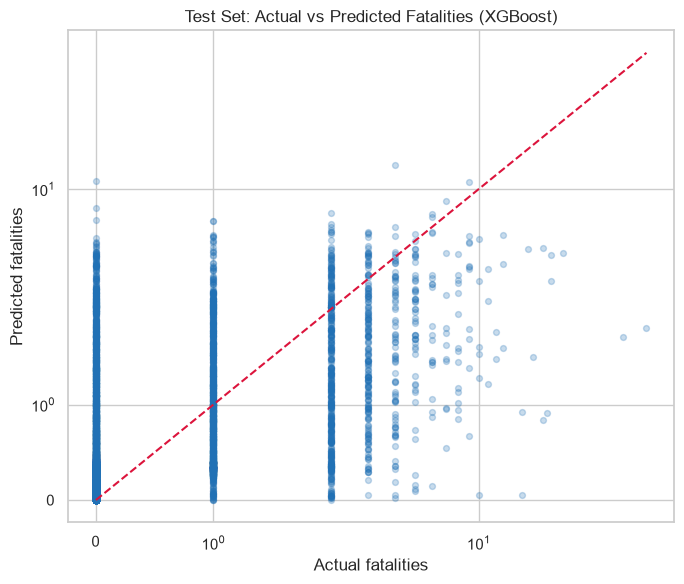

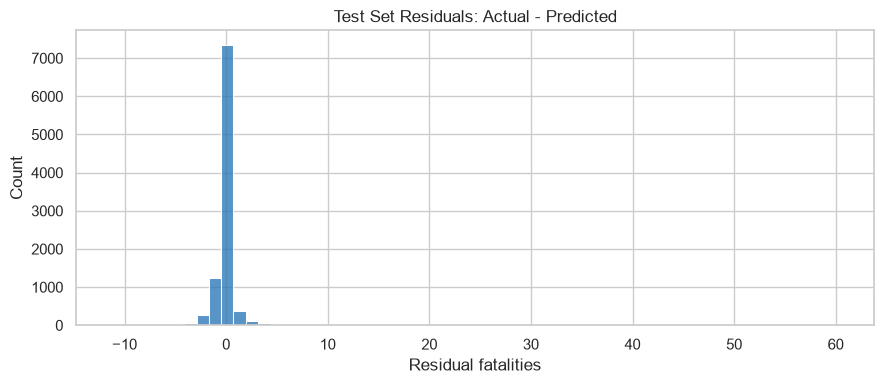

In [81]:
# Predicted vs actual plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test_actual, test_pred_actual, alpha=0.25, s=18, color="#2171b5")
plt.plot([0, y_test_actual.max()], [0, y_test_actual.max()], color="crimson", linestyle="--")
plt.title(f"Test Set: Actual vs Predicted Fatalities ({best_model_name})")
plt.xlabel("Actual fatalities")
plt.ylabel("Predicted fatalities")
plt.xscale("symlog")
plt.yscale("symlog")
plt.tight_layout()
plt.show()

# Residual distribution
residuals = y_test_actual.values - test_pred_actual
plt.figure(figsize=(9, 4))
sns.histplot(residuals, bins=60, color="#2171b5")
plt.title("Test Set Residuals: Actual - Predicted")
plt.xlabel("Residual fatalities")
plt.tight_layout()
plt.show()

6.13 Error Analysis by Severity Band
This is the section a judge or employer will look for.
Overall metrics can hide the fact that the model performs well on zero-fatality rows but poorly on rare severe weeks.

,rows,actual_fatalities,predicted_fatalities,mae,median_abs_error
SEVERITY_BAND,,,,,
0 None,7605,0,"2,189.738",0.288,0.058
1 Low (1-4),1823,2785,"2,170.073",0.861,0.657
2 Moderate (5-19),124,881,299.430,4.787,4.272
3 Severe (20+),8,240,21.058,27.368,19.629


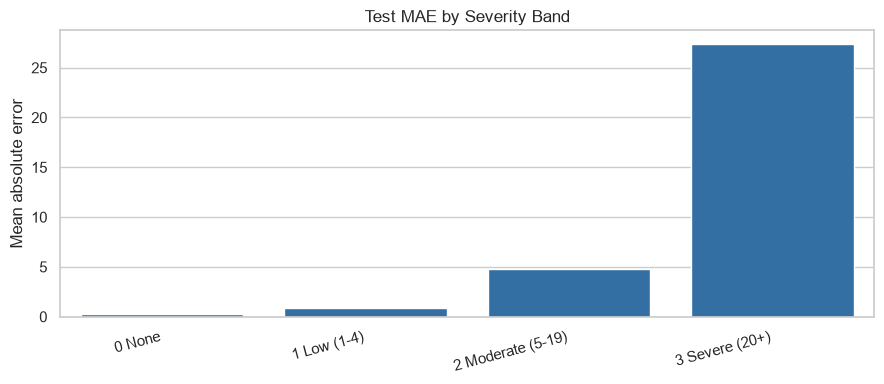

In [82]:
test_diagnostics = model_df.loc[test_mask, ["WEEK", "YEAR", "COUNTY", "EVENT_TYPE", "SUB_EVENT_TYPE", "TARGET_FATALITIES", "SEVERITY_BAND"]].copy()
test_diagnostics["PREDICTED_FATALITIES"] = test_pred_actual
test_diagnostics["ABS_ERROR"] = (test_diagnostics["TARGET_FATALITIES"] - test_diagnostics["PREDICTED_FATALITIES"]).abs()
test_diagnostics["RESIDUAL"] = test_diagnostics["TARGET_FATALITIES"] - test_diagnostics["PREDICTED_FATALITIES"]

severity_error = (
    test_diagnostics
    .groupby("SEVERITY_BAND")
    .agg(
        rows=("SEVERITY_BAND", "size"),
        actual_fatalities=("TARGET_FATALITIES", "sum"),
        predicted_fatalities=("PREDICTED_FATALITIES", "sum"),
        mae=("ABS_ERROR", "mean"),
        median_abs_error=("ABS_ERROR", "median"),
    )
)

display(severity_error)

plt.figure(figsize=(9, 4))
sns.barplot(data=severity_error.reset_index(), x="SEVERITY_BAND", y="mae", color="#2171b5")
plt.title("Test MAE by Severity Band")
plt.xlabel("")
plt.ylabel("Mean absolute error")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [83]:
# Show the largest misses because they reveal where the model is operationally risky.
largest_errors = test_diagnostics.sort_values("ABS_ERROR", ascending=False).head(15)
display(largest_errors)

,WEEK,YEAR,COUNTY,EVENT_TYPE,SUB_EVENT_TYPE,TARGET_FATALITIES,SEVERITY_BAND,PREDICTED_FATALITIES,ABS_ERROR,RESIDUAL
6855,2023-07-29,2023,Lamu,Battles,Armed clash,62,3 Severe (20+),1.801,60.199,60.199
15583,2025-02-22,2025,Turkana,Battles,Armed clash,48,3 Severe (20+),1.708,46.292,46.292
7911,2023-07-01,2023,Mandera,Battles,Armed clash,25,3 Severe (20+),4.259,20.741,20.741
13724,2024-08-31,2024,Nyeri,Riots,Mob violence,21,3 Severe (20+),0.906,20.094,20.094
1930,2022-01-08,2022,Garissa,Explosions/Remote violence,Remote explosive/landmine/IED,20,3 Severe (20+),0.836,19.164,19.164
6869,2023-09-09,2023,Lamu,Explosions/Remote violence,Remote explosive/landmine/IED,22,3 Severe (20+),2.918,19.082,19.082
15443,2022-09-24,2022,Turkana,Battles,Armed clash,22,3 Severe (20+),4.118,17.882,17.882
6835,2023-01-28,2023,Lamu,Explosions/Remote violence,Remote explosive/landmine/IED,18,2 Moderate (5-19),1.501,16.499,16.499
12655,2026-05-23,2026,Nakuru,Riots,Violent demonstration,16,2 Moderate (5-19),0.055,15.945,15.945
6809,2022-01-15,2022,Lamu,Battles,Armed clash,20,3 Severe (20+),4.511,15.489,15.489


6.14 County-Level Risk Ranking
The stakeholder-friendly output is not only row-level predictions.
Decision-makers need a county-level view: where should monitoring, mediation, or preparedness be prioritised?
This table aggregates predictions across the test period and compares them with actual fatalities.

,predicted_total_fatalities,actual_total_fatalities,predicted_mean_fatalities,actual_mean_fatalities,severe_weeks_actual,rows,risk_rank
COUNTY,,,,,,,
Nairobi,532.465,289,0.616,0.334,0,865,1
Mandera,361.283,256,1.537,1.089,1,235,2
Turkana,341.786,263,1.280,0.985,2,267,3
Samburu,339.199,154,1.563,0.710,0,217,4
Baringo,246.378,126,0.940,0.481,0,262,5
Isiolo,222.788,142,1.071,0.683,0,208,6
Garissa,208.918,272,0.839,1.092,1,249,7
Lamu,183.198,298,1.047,1.703,3,175,8
Machakos,171.248,81,0.601,0.284,0,285,9


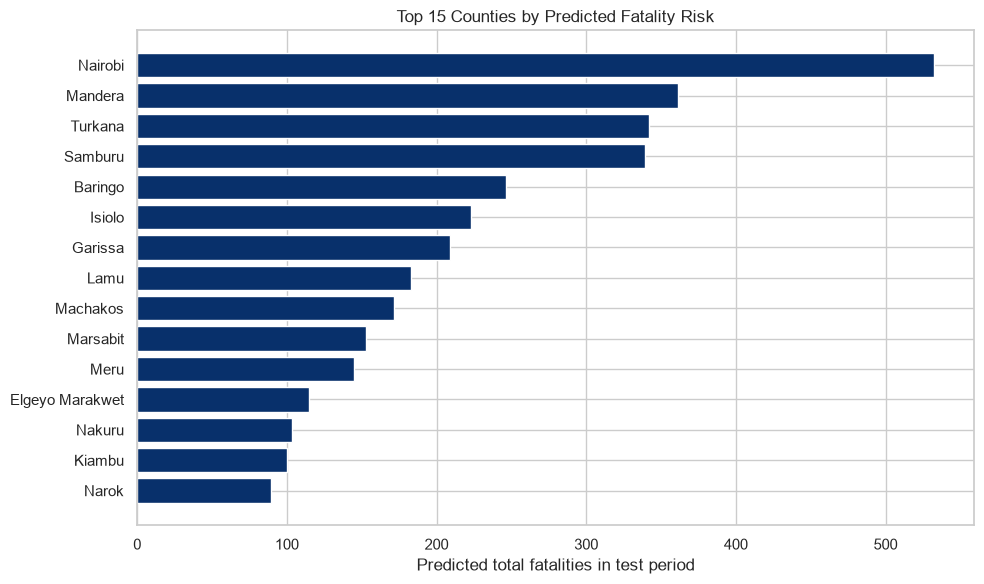

In [84]:
county_risk = (
    test_diagnostics
    .groupby("COUNTY")
    .agg(
        predicted_total_fatalities=("PREDICTED_FATALITIES", "sum"),
        actual_total_fatalities=("TARGET_FATALITIES", "sum"),
        predicted_mean_fatalities=("PREDICTED_FATALITIES", "mean"),
        actual_mean_fatalities=("TARGET_FATALITIES", "mean"),
        severe_weeks_actual=("TARGET_FATALITIES", lambda s: (s >= 20).sum()),
        rows=("COUNTY", "size"),
    )
    .sort_values("predicted_total_fatalities", ascending=False)
)

county_risk["risk_rank"] = range(1, len(county_risk) + 1)
display(county_risk.head(15))

plt.figure(figsize=(10, 6))
top_risk = county_risk.head(15).sort_values("predicted_total_fatalities")
plt.barh(top_risk.index, top_risk["predicted_total_fatalities"], color="#08306b")
plt.title("Top 15 Counties by Predicted Fatality Risk")
plt.xlabel("Predicted total fatalities in test period")
plt.tight_layout()
plt.show()

6.15 Feature Importance
Feature importance is used for explanation, not blind trust.
For the final model:
If the model exposes native feature importance, we inspect it.
We also calculate permutation importance on the validation set, which asks: how much does performance worsen when this feature is shuffled?

,feature,importance
78,DISORDER_TYPE_Political violence,0.247
77,DISORDER_TYPE_Demonstrations,0.050
81,EVENTS,0.045
51,EVENT_TYPE_Strategic developments,0.042
50,EVENT_TYPE_Riots,0.031
98,CENTROID_LATITUDE,0.027
42,COUNTY_Turkana,0.021
53,SUB_EVENT_TYPE_Abduction/forced disappearance,0.020
47,EVENT_TYPE_Battles,0.017
58,SUB_EVENT_TYPE_Attack,0.017


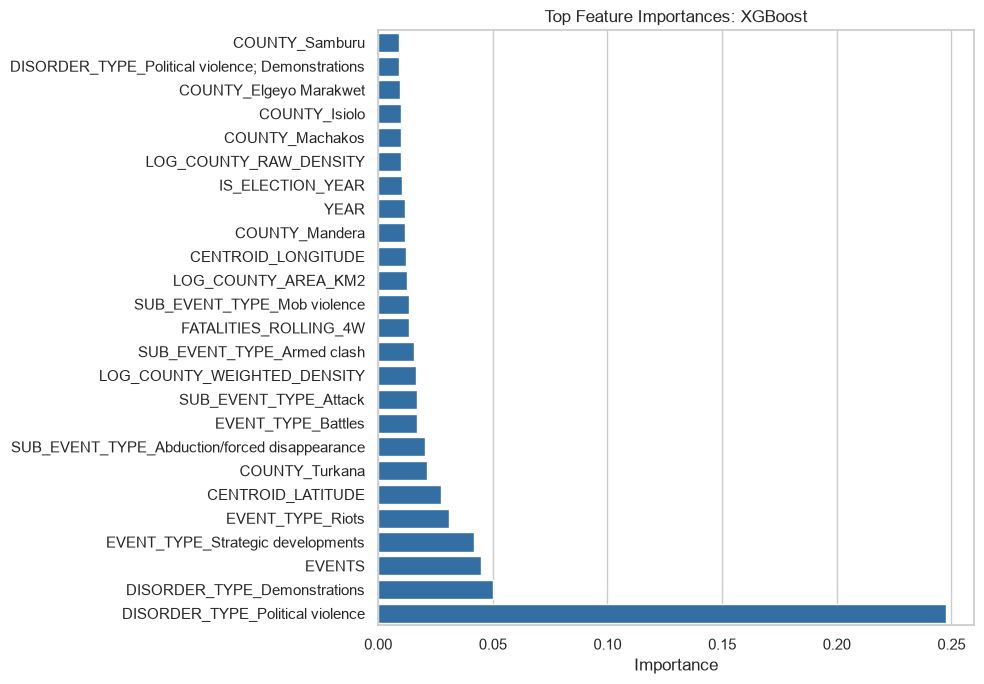

In [85]:
# Get transformed feature names from the preprocessor.
fitted_preprocessor = best_model.named_steps["preprocessor"]

cat_names = fitted_preprocessor.named_transformers_["categorical"].get_feature_names_out(categorical_features)
feature_names = np.r_[cat_names, numeric_features]

model_estimator = best_model.named_steps["model"]

if hasattr(model_estimator, "feature_importances_"):
    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": model_estimator.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .head(25)
    )

    display(importance_df)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=importance_df.sort_values("importance"), x="importance", y="feature", color="#2171b5")
    plt.title(f"Top Feature Importances: {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose native feature_importances_. Use permutation importance below.")

,feature,importance_mean,importance_std
3,DISORDER_TYPE,0.204,0.029
4,EVENTS,0.143,0.013
1,EVENT_TYPE,0.052,0.008
2,SUB_EVENT_TYPE,0.044,0.011
19,LOG_COUNTY_WEIGHTED_DENSITY,0.035,0.004
8,FATALITIES_ROLLING_4W,0.016,0.005
20,LOG_COUNTY_URBAN_CORE_DENSITY,0.013,0.003
0,COUNTY,0.010,0.005
21,CENTROID_LATITUDE,0.005,0.003
22,CENTROID_LONGITUDE,0.005,0.003


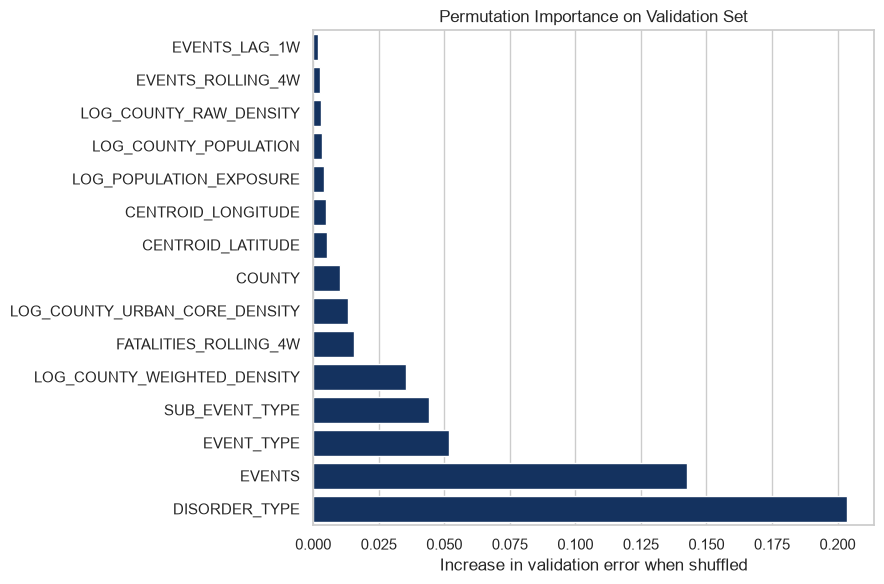

In [86]:
# Permutation importance on a sample keeps the notebook practical while still giving honest signal.
valid_sample_size = min(2500, len(X_valid))
valid_sample = X_valid.sample(valid_sample_size, random_state=RANDOM_STATE)
y_valid_sample_actual = y_valid_actual.loc[valid_sample.index]

def neg_rmse_scorer(estimator, X_sample, y_sample_log):
    pred_actual = inverse_log_predictions(estimator.predict(X_sample))
    return -np.sqrt(mean_squared_error(np.expm1(y_sample_log), pred_actual))

perm = permutation_importance(
    best_model,
    valid_sample,
    y_valid_log.loc[valid_sample.index],
    scoring=neg_rmse_scorer,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_df = (
    pd.DataFrame({
        "feature": X_valid.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)

display(permutation_df.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(data=permutation_df.head(15).sort_values("importance_mean"),
            x="importance_mean", y="feature", color="#08306b")
plt.title("Permutation Importance on Validation Set")
plt.xlabel("Increase in validation error when shuffled")
plt.ylabel("")
plt.tight_layout()
plt.show()

6.16 Optional SHAP Interpretation
SHAP is useful for the final presentation because it explains model predictions in a way stakeholders can understand.
This cell runs only if SHAP is installed and the final model is compatible. If it fails, the project still has permutation importance as a reliable fallback.

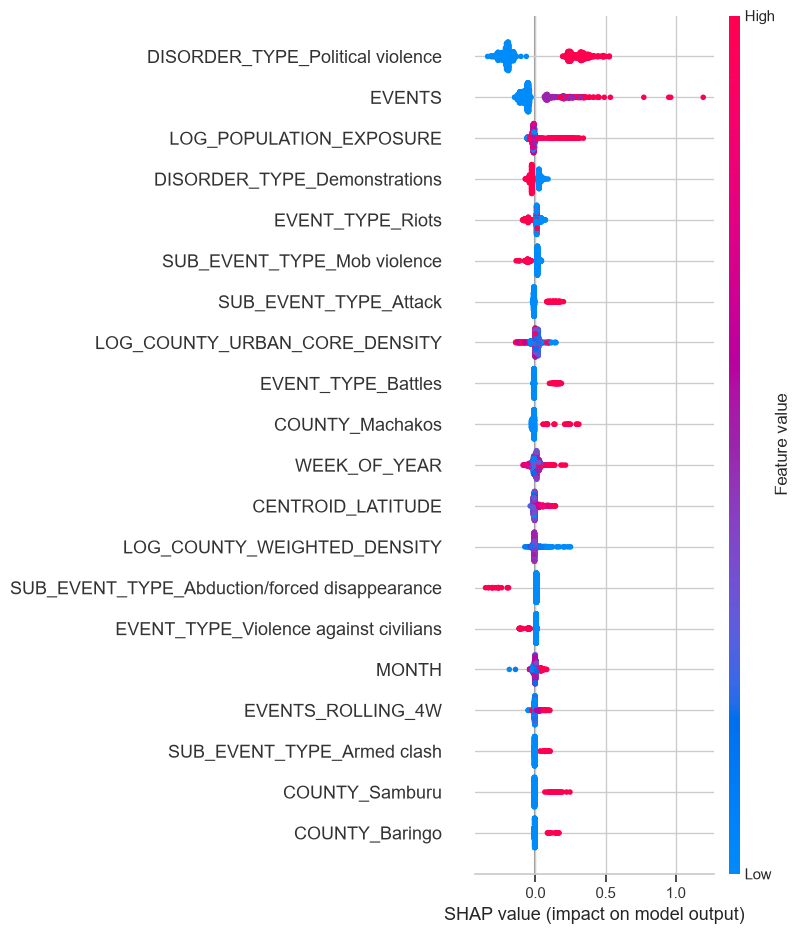

In [87]:
if HAS_SHAP and hasattr(model_estimator, "feature_importances_"):
    # Transform a sample to keep SHAP computation manageable.
    shap_sample = X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE)
    X_shap = fitted_preprocessor.transform(shap_sample)

    try:
        explainer = shap.Explainer(model_estimator, X_shap, feature_names=feature_names)
        shap_values = explainer(X_shap)
        shap.summary_plot(shap_values, X_shap, feature_names=feature_names, max_display=20)
    except Exception as e:
        print("SHAP could not be generated for this model/environment.")
        print(e)
else:
    print("SHAP skipped. Use permutation importance for interpretation.")

6.17 Production Refit
After the final test evaluation, the deployment artifact should be refit on all non-test data: train + validation.
This does not change the test metrics reported above. The test metrics remain the honest backtest from the model selected using validation. The refit model is simply a stronger production artifact because it learns from all data available before the held-out test window.

In [88]:
# Refit the selected model on train + validation data for deployment.
dev_mask = model_df["YEAR"] <= 2021
X_dev = X.loc[dev_mask]
y_dev_log = y_log.loc[dev_mask]

production_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", clone(models[best_model_name])),
])

production_pipeline.fit(X_dev, y_dev_log)

print(f"Production model refit complete: {best_model_name}")
print(f"Rows used for production refit: {len(X_dev):,}")

Production model refit complete: XGBoost
Rows used for production refit: 7,067


6.18 Save Model Artifacts
The final pipeline includes preprocessing and the trained model, so it can be reused without manually repeating one-hot encoding or scaling.
This is what makes the modelling section deployment-ready.

In [89]:
import joblib

ARTIFACT_DIR = Path("model_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

model_path = ARTIFACT_DIR / "kenya_fatality_severity_model.joblib"
metrics_path = ARTIFACT_DIR / "model_test_metrics.csv"
validation_metrics_path = ARTIFACT_DIR / "model_validation_metrics.csv"
county_risk_path = ARTIFACT_DIR / "county_risk_ranking.csv"
diagnostics_path = ARTIFACT_DIR / "test_prediction_diagnostics.csv"

joblib.dump(production_pipeline, model_path)
test_results_df.to_csv(metrics_path, index=False)
validation_results_df.to_csv(validation_metrics_path, index=False)
county_risk.to_csv(county_risk_path)
test_diagnostics.to_csv(diagnostics_path, index=False)

print("Saved:")
print("-", model_path)
print("-", metrics_path)
print("-", validation_metrics_path)
print("-", county_risk_path)
print("-", diagnostics_path)

Saved:
- model_artifacts\kenya_fatality_severity_model.joblib
- model_artifacts\model_test_metrics.csv
- model_artifacts\model_validation_metrics.csv
- model_artifacts\county_risk_ranking.csv
- model_artifacts\test_prediction_diagnostics.csv


6.19 Modelling Section Conclusions
From a professional review standpoint, the modelling section is complete only if it answers five questions:
Does the model beat a dummy baseline?
If not, the dataset/features are not yet useful enough for deployment.

Does it perform acceptably on the 2022-2026 test period?
This is the closest estimate of future performance.

Does it handle severe events, not only zero-fatality weeks?
The severe-event diagnostics answer this directly.

Can decision-makers understand the drivers?
Feature importance, permutation importance, and optional SHAP provide the explanation layer.

Can the result become a product?
The saved pipeline and county risk ranking are the bridge into deployment and presentation.

Critical self-critique:
This model should not be presented as a fully automated violence oracle. It is a decision-support tool built from historical event data. ACLED reporting bias, rare-event instability, county-level structural inequality, and changing political contexts must be stated clearly in the final report. The correct professional claim is: the model can prioritise monitoring and preparedness, not replace human judgement.